#  XGBoost  Training— Respira SP

Este notebook dá continuidade à preparação dos dados, utilizando os datasets supervisionados gerados anteriormente para treinar e avaliar um modelo XGBoost na previsão de PM2.5 24 horas à frente.

## O que foi feito

- Carregamento dos datasets supervisionados referentes às três estratégias de pré-processamento;
- Remoção da coluna `MP2.5` original para evitar seu uso direto como feature no modelo;
- Definição das features utilizadas no treinamento e do target `target_24h`;
- Realização do `split temporal` dos dados:
- Treino: dados ***anteriores a 2018***;
- Validação: ***dados de 2018***;
- Teste: ***dados de 2019***;
- Criação de uma pipeline com SimpleImputer, garantindo que o ajuste do imputer seja feito apenas nos dados de treino;
- Transformação dos dados de validação e teste utilizando apenas o objeto ajustado no treino, evitando data leakage;
- Treinamento de um baseline simples baseado em `PM2.5_lag_24h`;
- Treinamento inicial do modelo ***XGBoos***t para cada estratégia de pré-processamento;
- Avaliação dos modelos com `MAE, RMSE e R²`;
- Comparação entre `baseline` e `XGBoost` no conjunto de validação;
- Avaliação final do `XGBoost` no conjunto de teste;
- Análise de `feature importance`;
- Análise de `desempenho por split`;
- Construção de `learning curves` para investigar possíveis sinais de overfitting, underfitting ou data leakage.


## Observação

Nesta etapa, o foco foi criar uma primeira versão funcional do modelo XGBoost e comparar o desempenho entre as três estratégias de pré-processamento. A otimização de hiperparâmetros será realizada posteriormente.

***Parece estar com tendencia de overfitting***

Esta versão utiliza a base histórica de ***2013 a 2019*** e mantém todas as features meteorológicas disponíveis:

- `temperature_2m`
- `relative_humidity_2m`
- `precipitation`
- `wind_speed_10m`

A ideia é comparar esta abordagem com o pré-processamento anterior do grupo, avaliando posteriormente qual estratégia gera melhor desempenho nos modelos.

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, TimeSeriesSplit

In [25]:
# Importando as bases de dados 2013-2019
# Estrategia 1 sem imterpolação temporal / sazonal
df_estrategia01 = pd.read_csv("../data/processed_data/xgb_estrategia01_2013_2019_target_24h.csv")
df_estrategia01.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,target_24h,mes,hora,dia_semana,PM2.5_lag_1h,PM2.5_lag_3h,PM2.5_lag_6h,PM2.5_lag_12h,PM2.5_lag_24h,PM2.5_rolling_mean_3h,PM2.5_rolling_mean_6h,PM2.5_rolling_mean_12h,PM2.5_rolling_mean_24h,PM2.5_rolling_std_24h
0,2013-05-12 01:00:00+00:00,41.0,15.951,99.363174,0.0,6.193674,62.0,5,1,6,36.0,29.0,32.0,26.0,7.0,32.000000,34.333333,30.000000,27.333333,12.950295
1,2013-05-12 02:00:00+00:00,55.0,15.601,99.680275,0.0,6.915374,68.0,5,2,6,41.0,31.0,40.0,24.0,72.0,36.000000,35.833333,31.250000,28.750000,12.480419
2,2013-05-12 03:00:00+00:00,52.0,15.351,99.360230,0.0,6.439876,70.0,5,3,6,55.0,36.0,38.0,31.0,44.0,44.000000,38.333333,33.833333,28.041667,10.191553
3,2013-05-12 04:00:00+00:00,39.0,15.101,99.358990,0.0,6.725354,66.0,5,4,6,52.0,41.0,29.0,27.0,25.0,49.333333,40.666667,35.583333,28.375000,10.846007
4,2013-05-12 05:00:00+00:00,22.0,14.751,99.357250,0.0,5.447788,80.0,5,5,6,39.0,55.0,31.0,21.0,18.0,48.666667,42.333333,36.583333,28.958333,11.031493


In [26]:
# Estrategia 2 com imterpolação tempora em gaps menores 
df_estrategia02 = pd.read_csv("../data/processed_data/xgb_estrategia02_2013_2019_target_24h.csv")
df_estrategia02.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,target_24h,mes,hora,dia_semana,PM2.5_lag_1h,PM2.5_lag_3h,PM2.5_lag_6h,PM2.5_lag_12h,PM2.5_lag_24h,PM2.5_rolling_mean_3h,PM2.5_rolling_mean_6h,PM2.5_rolling_mean_12h,PM2.5_rolling_mean_24h,PM2.5_rolling_std_24h
0,2013-05-10 03:00:00+00:00,32.0,11.601000,99.670166,0.0,3.893995,44.0,5,3,4,39.0,12.0,32.0,27.0,26.0,18.000000,22.666667,28.083333,24.875000,9.391543
1,2013-05-10 04:00:00+00:00,23.0,11.401000,99.669660,0.0,3.054701,25.0,5,4,4,32.0,3.0,29.0,24.0,21.0,24.666667,22.666667,28.500000,25.125000,9.502002
2,2013-05-10 05:00:00+00:00,18.0,11.201000,99.339226,0.0,4.582052,18.0,5,5,4,23.0,39.0,21.0,31.0,20.0,31.333333,21.666667,28.416667,25.208333,9.472978
3,2013-05-10 06:00:00+00:00,20.0,10.801001,99.337160,0.0,5.091168,15.0,5,6,4,18.0,32.0,12.0,42.0,18.0,24.333333,21.166667,27.333333,25.125000,9.529417
4,2013-05-10 07:00:00+00:00,32.0,10.701000,98.348854,0.0,5.091168,19.0,5,7,4,20.0,23.0,3.0,38.0,20.0,20.333333,22.500000,25.500000,25.208333,9.472978


In [27]:
# Estrategia 3 com imputação sazonal em gaps menores e imterpolação temporal em gaps menores
df_estrategia03 = pd.read_csv("../data/processed_data/xgb_estrategia03_2013_2019_target_24h.csv")
df_estrategia03.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,mes,hora,dia_semana,MP2.5_imputado_media,...,PM2.5_lag_1h,PM2.5_lag_3h,PM2.5_lag_6h,PM2.5_lag_12h,PM2.5_lag_24h,PM2.5_rolling_mean_3h,PM2.5_rolling_mean_6h,PM2.5_rolling_mean_12h,PM2.5_rolling_mean_24h,PM2.5_rolling_std_24h
0,2013-05-10 03:00:00+00:00,32.0,11.601000,99.670166,0.0,3.893995,5,3,4,0,...,39.0,12.0,32.0,27.0,26.0,18.000000,22.666667,28.083333,24.875000,9.391543
1,2013-05-10 04:00:00+00:00,23.0,11.401000,99.669660,0.0,3.054701,5,4,4,0,...,32.0,3.0,29.0,24.0,21.0,24.666667,22.666667,28.500000,25.125000,9.502002
2,2013-05-10 05:00:00+00:00,18.0,11.201000,99.339226,0.0,4.582052,5,5,4,0,...,23.0,39.0,21.0,31.0,20.0,31.333333,21.666667,28.416667,25.208333,9.472978
3,2013-05-10 06:00:00+00:00,20.0,10.801001,99.337160,0.0,5.091168,5,6,4,0,...,18.0,32.0,12.0,42.0,18.0,24.333333,21.166667,27.333333,25.125000,9.529417
4,2013-05-10 07:00:00+00:00,32.0,10.701000,98.348854,0.0,5.091168,5,7,4,0,...,20.0,23.0,3.0,38.0,20.0,20.333333,22.500000,25.500000,25.208333,9.472978


### fazer split temporal

In [28]:
df_estrategia01 = df_estrategia01.drop(columns='MP2.5')
df_estrategia01.head()

,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,target_24h,mes,hora,dia_semana,PM2.5_lag_1h,PM2.5_lag_3h,PM2.5_lag_6h,PM2.5_lag_12h,PM2.5_lag_24h,PM2.5_rolling_mean_3h,PM2.5_rolling_mean_6h,PM2.5_rolling_mean_12h,PM2.5_rolling_mean_24h,PM2.5_rolling_std_24h
0,2013-05-12 01:00:00+00:00,15.951,99.363174,0.0,6.193674,62.0,5,1,6,36.0,29.0,32.0,26.0,7.0,32.000000,34.333333,30.000000,27.333333,12.950295
1,2013-05-12 02:00:00+00:00,15.601,99.680275,0.0,6.915374,68.0,5,2,6,41.0,31.0,40.0,24.0,72.0,36.000000,35.833333,31.250000,28.750000,12.480419
2,2013-05-12 03:00:00+00:00,15.351,99.360230,0.0,6.439876,70.0,5,3,6,55.0,36.0,38.0,31.0,44.0,44.000000,38.333333,33.833333,28.041667,10.191553
3,2013-05-12 04:00:00+00:00,15.101,99.358990,0.0,6.725354,66.0,5,4,6,52.0,41.0,29.0,27.0,25.0,49.333333,40.666667,35.583333,28.375000,10.846007
4,2013-05-12 05:00:00+00:00,14.751,99.357250,0.0,5.447788,80.0,5,5,6,39.0,55.0,31.0,21.0,18.0,48.666667,42.333333,36.583333,28.958333,11.031493


In [29]:
df_estrategia02 = df_estrategia02.drop(columns='MP2.5')
df_estrategia02.head()

,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,target_24h,mes,hora,dia_semana,PM2.5_lag_1h,PM2.5_lag_3h,PM2.5_lag_6h,PM2.5_lag_12h,PM2.5_lag_24h,PM2.5_rolling_mean_3h,PM2.5_rolling_mean_6h,PM2.5_rolling_mean_12h,PM2.5_rolling_mean_24h,PM2.5_rolling_std_24h
0,2013-05-10 03:00:00+00:00,11.601000,99.670166,0.0,3.893995,44.0,5,3,4,39.0,12.0,32.0,27.0,26.0,18.000000,22.666667,28.083333,24.875000,9.391543
1,2013-05-10 04:00:00+00:00,11.401000,99.669660,0.0,3.054701,25.0,5,4,4,32.0,3.0,29.0,24.0,21.0,24.666667,22.666667,28.500000,25.125000,9.502002
2,2013-05-10 05:00:00+00:00,11.201000,99.339226,0.0,4.582052,18.0,5,5,4,23.0,39.0,21.0,31.0,20.0,31.333333,21.666667,28.416667,25.208333,9.472978
3,2013-05-10 06:00:00+00:00,10.801001,99.337160,0.0,5.091168,15.0,5,6,4,18.0,32.0,12.0,42.0,18.0,24.333333,21.166667,27.333333,25.125000,9.529417
4,2013-05-10 07:00:00+00:00,10.701000,98.348854,0.0,5.091168,19.0,5,7,4,20.0,23.0,3.0,38.0,20.0,20.333333,22.500000,25.500000,25.208333,9.472978


In [30]:
df_estrategia03 = df_estrategia03.drop(columns='MP2.5')
df_estrategia03.head()

,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,mes,hora,dia_semana,MP2.5_imputado_media,target_24h,PM2.5_lag_1h,PM2.5_lag_3h,PM2.5_lag_6h,PM2.5_lag_12h,PM2.5_lag_24h,PM2.5_rolling_mean_3h,PM2.5_rolling_mean_6h,PM2.5_rolling_mean_12h,PM2.5_rolling_mean_24h,PM2.5_rolling_std_24h
0,2013-05-10 03:00:00+00:00,11.601000,99.670166,0.0,3.893995,5,3,4,0,44.0,39.0,12.0,32.0,27.0,26.0,18.000000,22.666667,28.083333,24.875000,9.391543
1,2013-05-10 04:00:00+00:00,11.401000,99.669660,0.0,3.054701,5,4,4,0,25.0,32.0,3.0,29.0,24.0,21.0,24.666667,22.666667,28.500000,25.125000,9.502002
2,2013-05-10 05:00:00+00:00,11.201000,99.339226,0.0,4.582052,5,5,4,0,18.0,23.0,39.0,21.0,31.0,20.0,31.333333,21.666667,28.416667,25.208333,9.472978
3,2013-05-10 06:00:00+00:00,10.801001,99.337160,0.0,5.091168,5,6,4,0,15.0,18.0,32.0,12.0,42.0,18.0,24.333333,21.166667,27.333333,25.125000,9.529417
4,2013-05-10 07:00:00+00:00,10.701000,98.348854,0.0,5.091168,5,7,4,0,19.0,20.0,23.0,3.0,38.0,20.0,20.333333,22.500000,25.500000,25.208333,9.472978


In [81]:
#Selecionando as features para o modelo
features = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "wind_speed_10m",
    "mes",
    "hora",
    "dia_semana",
    "PM2.5_lag_1h",
    "PM2.5_lag_3h",
    "PM2.5_lag_6h",
    "PM2.5_lag_12h",
    "PM2.5_lag_24h",
    "PM2.5_rolling_mean_3h",
    "PM2.5_rolling_mean_6h",
    "PM2.5_rolling_mean_12h",
    "PM2.5_rolling_mean_24h",
    "PM2.5_rolling_std_24h"
]

target = "target_24h"

In [32]:
df_estrategia01["time"] = pd.to_datetime(df_estrategia01["time"])
df_estrategia02["time"] = pd.to_datetime(df_estrategia02["time"])
df_estrategia03["time"] = pd.to_datetime(df_estrategia03["time"])

In [82]:
#função para split temporal
def split_temporal(df, features, target):
    df = df.sort_values("time").copy()

    train = df[df["time"] < "2018-01-01"].copy()
    val = df[(df["time"] >= "2018-01-01") & (df["time"] < "2019-01-01")].copy()
    test = df[df["time"] >= "2019-01-01"].copy()

    X_train = train[features]
    y_train = train[target]

    X_val = val[features]
    y_val = val[target]

    X_test = test[features]
    y_test = test[target]

    return X_train, X_val, X_test, y_train, y_val, y_test

In [36]:
#split na 1 estrategia
X_train_01, X_val_01, X_test_01, y_train_01, y_val_01, y_test_01 = split_temporal(
    df_estrategia01, features, target
)

In [37]:
#split na 2 estrategia
X_train_02, X_val_02, X_test_02, y_train_02, y_val_02, y_test_02 = split_temporal(
    df_estrategia02, features, target
)

In [38]:
#split na 3 estrategia
X_train_03, X_val_03, X_test_03, y_train_03, y_val_03, y_test_03 = split_temporal(
    df_estrategia03, features, target
)

In [39]:
print(X_train_01.shape, X_val_01.shape, X_test_01.shape)
print(X_train_02.shape, X_val_02.shape, X_test_02.shape)
print(X_train_03.shape, X_val_03.shape, X_test_03.shape)

(34790, 17) (7475, 17) (5010, 17)
(37817, 17) (7604, 17) (5221, 17)
(40725, 17) (8760, 17) (5475, 17)


In [83]:
#vendo se ainda reside nan nos X
print(X_train_01.isna().sum().sum(), X_val_01.isna().sum().sum(), X_test_01.isna().sum().sum())
print(X_train_02.isna().sum().sum(), X_val_02.isna().sum().sum(), X_test_02.isna().sum().sum())
print(X_train_03.isna().sum().sum(), X_val_03.isna().sum().sum(), X_test_03.isna().sum().sum())

0 0 0
0 0 0
0 0 0


In [84]:
#vendo se ainda reside nan nos Y
print(y_train_01.isna().sum(), y_val_01.isna().sum(), y_test_01.isna().sum())
print(y_train_02.isna().sum(), y_val_02.isna().sum(), y_test_02.isna().sum())
print(y_train_03.isna().sum(), y_val_03.isna().sum(), y_test_03.isna().sum())

0 0 0
0 0 0
0 0 0


### Avaliação Baseline 

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [47]:
def avaliar_modelo(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

In [48]:
y_pred_baseline_01 = X_val_01["PM2.5_lag_24h"]
y_pred_baseline_02 = X_val_02["PM2.5_lag_24h"]
y_pred_baseline_03 = X_val_03["PM2.5_lag_24h"]

baseline_01 = avaliar_modelo(y_val_01, y_pred_baseline_01)
baseline_02 = avaliar_modelo(y_val_02, y_pred_baseline_02)
baseline_03 = avaliar_modelo(y_val_03, y_pred_baseline_03)

baseline_01, baseline_02, baseline_03

({'MAE': 11.016989966555183,
  'RMSE': 15.610750090711491,
  'R2': -0.39173078414061124},
 {'MAE': 11.028581448360514,
  'RMSE': 15.646441218400593,
  'R2': -0.411274593292444},
 {'MAE': 10.51950426132376,
  'RMSE': 15.012342447173122,
  'R2': -0.4051236520504613})

### Pipeline do Modelo XGBoost - Utilizando Simple Imputer 

In [49]:
def train(X_train, y_train, X_val, y_val):
    pipeline = make_pipeline(
        SimpleImputer(strategy="median"),
        XGBRegressor(
            objective="reg:squarederror",
            n_estimators=500,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_val)

    resultados = {
        "MAE": mean_absolute_error(y_val, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_val, y_pred)),
        "R2": r2_score(y_val, y_pred)
    }

    return pipeline, y_pred, resultados

In [51]:
modelo_01, y_pred_val_01, resultados_xgb_01 = train(
    X_train_01, y_train_01, X_val_01, y_val_01
)

In [52]:
modelo_02, y_pred_val_02, resultados_xgb_02 = train(
    X_train_02, y_train_02, X_val_02, y_val_02
)

In [53]:
modelo_03, y_pred_val_03, resultados_xgb_03 = train(
    X_train_03, y_train_03, X_val_03, y_val_03
)

In [54]:
resultados_comparacao = pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "Baseline lag_24h", **baseline_01},
    {"estrategia": "Estratégia 1", "modelo": "XGBoost", **resultados_xgb_01},

    {"estrategia": "Estratégia 2", "modelo": "Baseline lag_24h", **baseline_02},
    {"estrategia": "Estratégia 2", "modelo": "XGBoost", **resultados_xgb_02},

    {"estrategia": "Estratégia 3", "modelo": "Baseline lag_24h", **baseline_03},
    {"estrategia": "Estratégia 3", "modelo": "XGBoost", **resultados_xgb_03},
])

resultados_comparacao

,estrategia,modelo,MAE,RMSE,R2
0,Estratégia 1,Baseline lag_24h,11.016990,15.610750,-0.391731
1,Estratégia 1,XGBoost,8.162475,11.284596,0.272757
2,Estratégia 2,Baseline lag_24h,11.028581,15.646441,-0.411275
3,Estratégia 2,XGBoost,8.188678,11.361140,0.255912
4,Estratégia 3,Baseline lag_24h,10.519504,15.012342,-0.405124
5,Estratégia 3,XGBoost,7.798056,10.957379,0.251432


In [55]:
y_pred_test_03 = modelo_03.predict(X_test_03)

resultados_test_03 = avaliar_modelo(y_test_03, y_pred_test_03)

resultados_test_03

{'MAE': 7.888167358487483,
 'RMSE': 10.881100969105814,
 'R2': 0.28562611536536064}

In [57]:
y_pred_test_01 = modelo_01.predict(X_test_01)
y_pred_test_02 = modelo_02.predict(X_test_02)
y_pred_test_03 = modelo_03.predict(X_test_03)

resultados_test_01 = avaliar_modelo(y_test_01, y_pred_test_01)
resultados_test_02 = avaliar_modelo(y_test_02, y_pred_test_02)
resultados_test_03 = avaliar_modelo(y_test_03, y_pred_test_03)

pd.DataFrame([
    {"estrategia": "Estratégia 1", "modelo": "XGBoost", "split": "Teste", **resultados_test_01},
    {"estrategia": "Estratégia 2", "modelo": "XGBoost", "split": "Teste", **resultados_test_02},
    {"estrategia": "Estratégia 3", "modelo": "XGBoost", "split": "Teste", **resultados_test_03},
])

,estrategia,modelo,split,MAE,RMSE,R2
0,Estratégia 1,XGBoost,Teste,7.843688,10.826835,0.278049
1,Estratégia 2,XGBoost,Teste,7.924267,10.965247,0.278327
2,Estratégia 3,XGBoost,Teste,7.888167,10.881101,0.285626


### No conjunto de teste, o XGBoost apresentou desempenho superior ao baseline, mantendo R² positivo nas três estratégias. A Estratégia 3 obteve o maior R² e desempenho competitivo em MAE e RMSE, indicando que a imputação sazonal pode ter contribuído para maior aproveitamento da série temporal. No entanto, as diferenças entre as estratégias foram pequenas, sugerindo que todas apresentam desempenho semelhante para a previsão de PM2.5 24 horas à frente.



In [59]:
modelo_xgb_03 = modelo_03.named_steps["xgbregressor"]
modelo_xgb_03.get_params()

{'objective': 'reg:squarederror',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.8,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.05,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 5,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 500,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': 0.8,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [60]:
feature_importance_03 = pd.DataFrame({
    "feature": X_train_03.columns,
    "importance": modelo_xgb_03.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_03

,feature,importance
7,PM2.5_lag_1h,0.175654
12,PM2.5_rolling_mean_3h,0.112533
5,hora,0.079221
13,PM2.5_rolling_mean_6h,0.073207
2,precipitation,0.071195
0,temperature_2m,0.064289
4,mes,0.046111
6,dia_semana,0.045195
3,wind_speed_10m,0.044014
15,PM2.5_rolling_mean_24h,0.042194


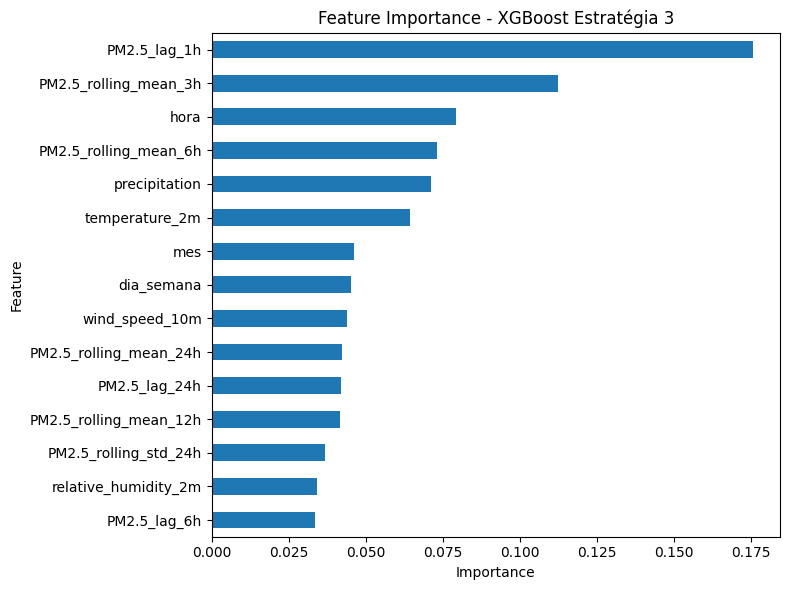

In [62]:
feature_importance_03.head(15).plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(8, 6),
    legend=False
)

plt.gca().invert_yaxis()
plt.title("Feature Importance - XGBoost Estratégia 3")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### o modelo está usando histórico recente, padrão horário e meteorologia como bengala para as previsões

In [63]:
def avaliar_splits_modelo(modelo, X_train, y_train, X_val, y_val, X_test, y_test):
    y_pred_train = modelo.predict(X_train)
    y_pred_val = modelo.predict(X_val)
    y_pred_test = modelo.predict(X_test)

    resultados = pd.DataFrame([
        {"split": "Train", **avaliar_modelo(y_train, y_pred_train)},
        {"split": "Validation", **avaliar_modelo(y_val, y_pred_val)},
        {"split": "Test", **avaliar_modelo(y_test, y_pred_test)},
    ])

    return resultados

### Vendo as diferenças das métricas entre treino-validação e teste

In [64]:
resultados_splits_03 = avaliar_splits_modelo(
    modelo_03,
    X_train_03, y_train_03,
    X_val_03, y_val_03,
    X_test_03, y_test_03
)

resultados_splits_03

,split,MAE,RMSE,R2
0,Train,6.891693,9.410215,0.520867
1,Validation,7.798056,10.957379,0.251432
2,Test,7.888167,10.881101,0.285626


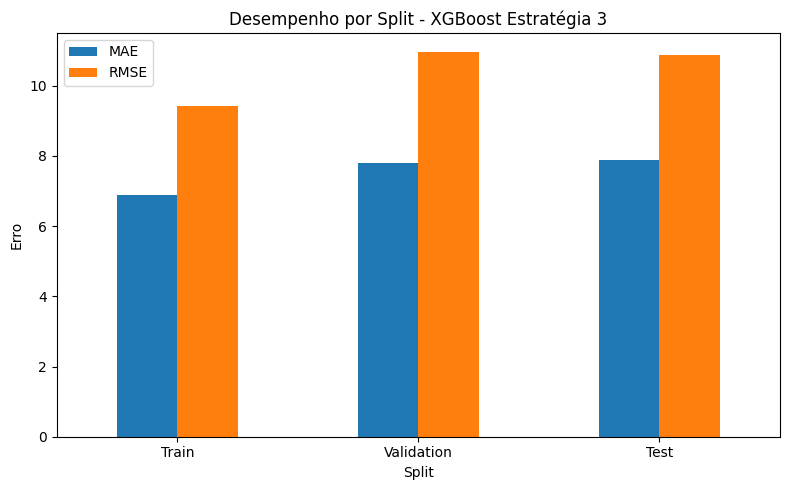

In [73]:
resultados_splits_03.plot(
    x="split",
    y=["MAE", "RMSE"],
    kind="bar",
    figsize=(8, 5)
)

plt.title("Desempenho por Split - XGBoost Estratégia 3")
plt.ylabel("Erro")
plt.xlabel("Split")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### O modelo parace treinar melhor no passado e generaliza de forma razoável. suspeita um pouco de overfitting

### Retreinar o modelo para ver o learning curve

In [67]:
pipeline_xgb = make_pipeline(
    SimpleImputer(strategy="median"),
    XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
)

In [69]:
tscv = TimeSeriesSplit(n_splits=5)

train_sizes, train_scores, val_scores = learning_curve(
    estimator=pipeline_xgb,
    X=X_train_03,
    y=y_train_03,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

In [71]:
train_rmse = -train_scores
val_rmse = -val_scores

train_rmse_mean = train_rmse.mean(axis=1)
train_rmse_std = train_rmse.std(axis=1)

val_rmse_mean = val_rmse.mean(axis=1)
val_rmse_std = val_rmse.std(axis=1)

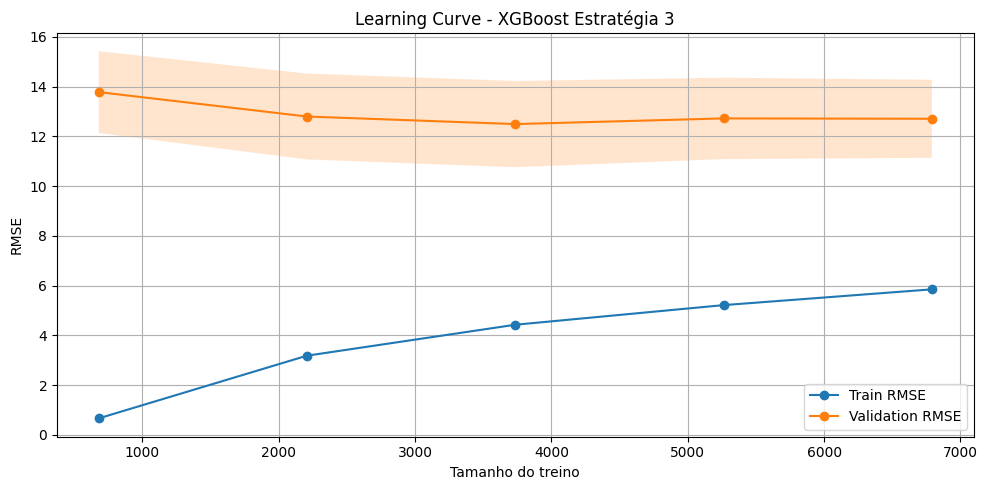

In [72]:
plt.figure(figsize=(10, 5))

plt.plot(train_sizes, train_rmse_mean, marker="o", label="Train RMSE")
plt.plot(train_sizes, val_rmse_mean, marker="o", label="Validation RMSE")

plt.fill_between(
    train_sizes,
    train_rmse_mean - train_rmse_std,
    train_rmse_mean + train_rmse_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_rmse_mean - val_rmse_std,
    val_rmse_mean + val_rmse_std,
    alpha=0.2
)

plt.title("Learning Curve - XGBoost Estratégia 3")
plt.xlabel("Tamanho do treino")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Isso sugere tendência de overfitting - alta variância. O modelo consegue se ajustar bem ao treino, mas não reduz tanto o erro de validação.

### Também dá para ver que a validação melhora no começo, mas depois estabiliza perto de RMSE 12–13. Isso indica que só aumentar os dados de treino, do jeito que está, não está melhorando muito.

In [74]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=pipeline_xgb,
    X=X_train_02,
    y=y_train_02,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

In [75]:
train_rmse = -train_scores
val_rmse = -val_scores

train_rmse_mean = train_rmse.mean(axis=1)
train_rmse_std = train_rmse.std(axis=1)

val_rmse_mean = val_rmse.mean(axis=1)
val_rmse_std = val_rmse.std(axis=1)

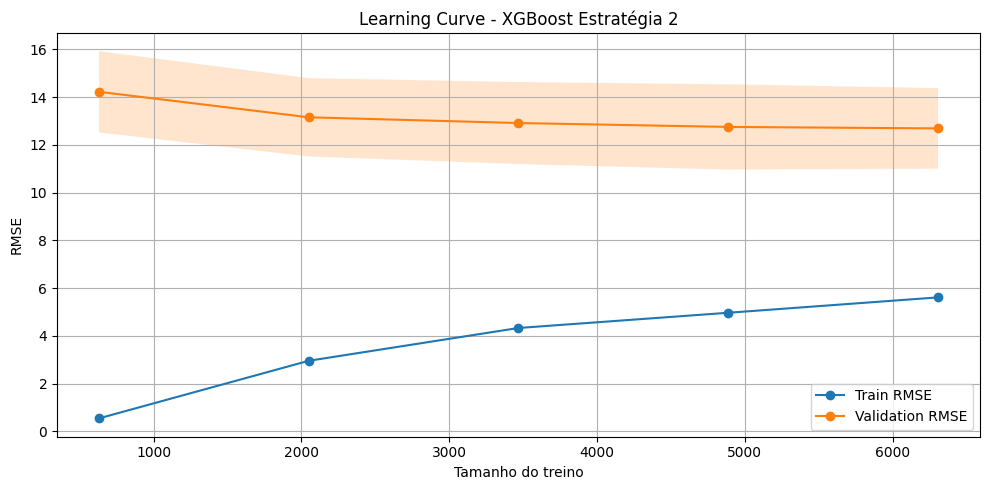

In [76]:
plt.figure(figsize=(10, 5))

plt.plot(train_sizes, train_rmse_mean, marker="o", label="Train RMSE")
plt.plot(train_sizes, val_rmse_mean, marker="o", label="Validation RMSE")

plt.fill_between(
    train_sizes,
    train_rmse_mean - train_rmse_std,
    train_rmse_mean + train_rmse_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_rmse_mean - val_rmse_std,
    val_rmse_mean + val_rmse_std,
    alpha=0.2
)

plt.title("Learning Curve - XGBoost Estratégia 2")
plt.xlabel("Tamanho do treino")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [77]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=pipeline_xgb,
    X=X_train_01,
    y=y_train_01,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

In [78]:
train_rmse = -train_scores
val_rmse = -val_scores

train_rmse_mean = train_rmse.mean(axis=1)
train_rmse_std = train_rmse.std(axis=1)

val_rmse_mean = val_rmse.mean(axis=1)
val_rmse_std = val_rmse.std(axis=1)

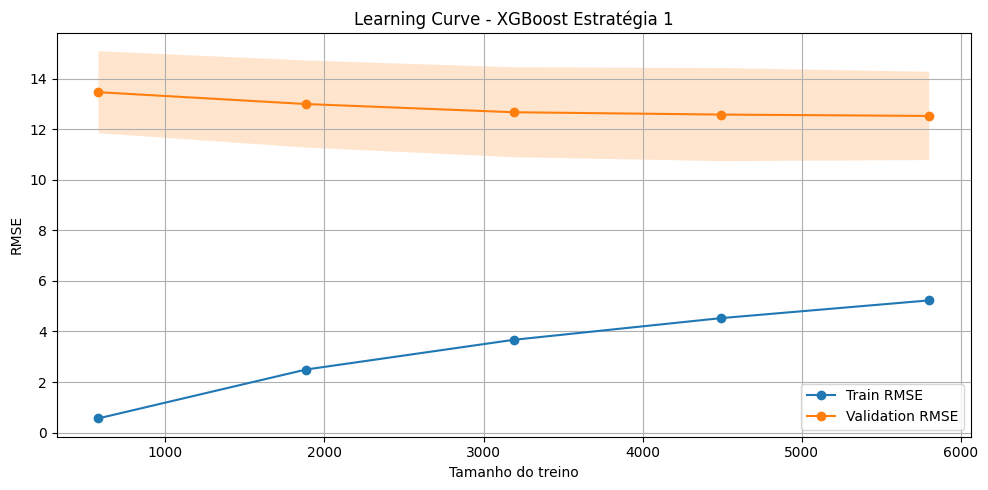

In [79]:
plt.figure(figsize=(10, 5))

plt.plot(train_sizes, train_rmse_mean, marker="o", label="Train RMSE")
plt.plot(train_sizes, val_rmse_mean, marker="o", label="Validation RMSE")

plt.fill_between(
    train_sizes,
    train_rmse_mean - train_rmse_std,
    train_rmse_mean + train_rmse_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_rmse_mean - val_rmse_std,
    val_rmse_mean + val_rmse_std,
    alpha=0.2
)

plt.title("Learning Curve - XGBoost Estratégia 1")
plt.xlabel("Tamanho do treino")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### As learning curves das três estratégias indicam uma diferença relevante entre o erro de treino e o erro de validação, sugerindo tendência de overfitting. A validação estabiliza após determinado volume de dados, indicando que apenas aumentar a quantidade de treino não reduz  o erro. Não há evidência clara de data leakage, pois o erro de validação permanece consideravelmente acima do erro de treino.

## Vou testar o modelo com hiperparâmetros diferentes